## Homework 2

> [!NOTE]
> This homework uses the pinned 2026 car fuel-efficiency release in the course
> repository. The plan and report are available in `cohorts/2026/data/`.

### Dataset

For this homework, we'll use the 2026 Car Fuel Efficiency dataset. Download it from <a href='https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'>here</a>.

You can do it with wget:
```bash
wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
```

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).



### Preparing the dataset 

Use only the following columns:

* `'engine_displacement'`,
* `'horsepower'`,
* `'vehicle_weight'`,
* `'model_year'`,
* `'fuel_efficiency_mpg'`

### EDA

* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 


In [1]:
import numpy as np 
import pandas as pd


In [4]:
raw_df = pd.read_csv("car_fuel_efficiency_2026.csv")
df = raw_df.copy()[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg']]


<Axes: >

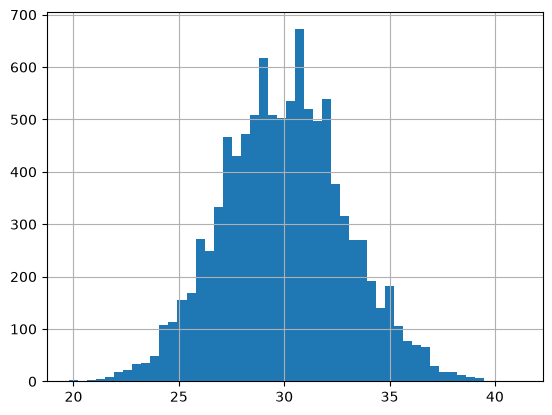

In [5]:
df.fuel_efficiency_mpg.hist(bins=50)

fuel efficiency no long tail


### Question 1

There's one column with missing values. What is it?

* `'engine_displacement'`
* `'horsepower'`
* `'vehicle_weight'`
* `'model_year'`



In [6]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Answer: "horsepower"


### Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354


In [7]:
df.horsepower.median()

np.float64(254.0)

Answer: 254.0

### Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture:

```python
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
```

For Q5, repeat the same block with each listed seed. For Q6, use seed `9`.



In [ ]:
def split_dataset_train_val_test(df, seed = 42, pct = 0.2):
    n = len(df)
    n_val = int(n*pct)
    n_test = int(n*pct)
    n_train = n-n_val-n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test= df.iloc[idx[n_train+n_val:]]

    return df_train, df_val, df_test

class ModelData:
    def __init__(self,X,y):
        self.X = X
        self.y = y

    def __repr__(self):
        return f"X: {self.X}\ny: {self.y}"


def split_target(df, target_columns:list[str], training_columns:list[str]|None=None):
    S = ModelData(None,None)
    if not training_columns:
        training_columns = list(set(df.columns).difference(set(target_columns)))
    S.X = df[training_columns]
    S.y = df[target_columns]

    return S

def generate_data_dictionary() 

In [11]:
for df in split_dataset_train_val_test(df):
    print(split_target(df,['horsepower']))

X:       engine_displacement  model_year  fuel_efficiency_mpg  vehicle_weight
6252                 1900        2015                 32.5            3790
4684                 2000        1992                 29.1            4380
1731                 2330        2022                 34.1            4090
4742                 2300        1997                 30.6            4150
4521                 2340        2001                 30.7            4400
...                   ...         ...                  ...             ...
7895                 2280        2018                 29.8            4590
9590                 2300        1984                 25.1            4240
7288                 2240        1989                 27.7            4190
278                  2430        2020                 31.6            4280
3252                 2390        1996                 28.0            4220

[6000 rows x 4 columns]
y:       horsepower
6252       239.0
4684       224.0
1731       286.0
4


### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good


### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02
* The numerical options are calculated from the pinned 2026 release. Use the value that matches your calculation; do not choose a merely close value.